In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import xarray as xr
from glob import glob
import os
from netCDF4 import Dataset
import pandas as pd
from datetime import datetime, date, timedelta
from pathlib import Path
import scipy
import scipy.ndimage
from mpl_toolkits.axes_grid1 import ImageGrid
import math
import cc3d

from mpl_toolkits.axes_grid1 import make_axes_locatable

t = 0

input_path = Path("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS")
fname = "slab_entrainment_stats.nc"
file_path = input_path / fname

In [2]:
ds_e = xr.open_dataset(file_path, group="Sum/Domain/Cloud/Entrainment")
ds_e["e"].isel(time=t).z.values

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS/slab_entrainment_stats.nc'

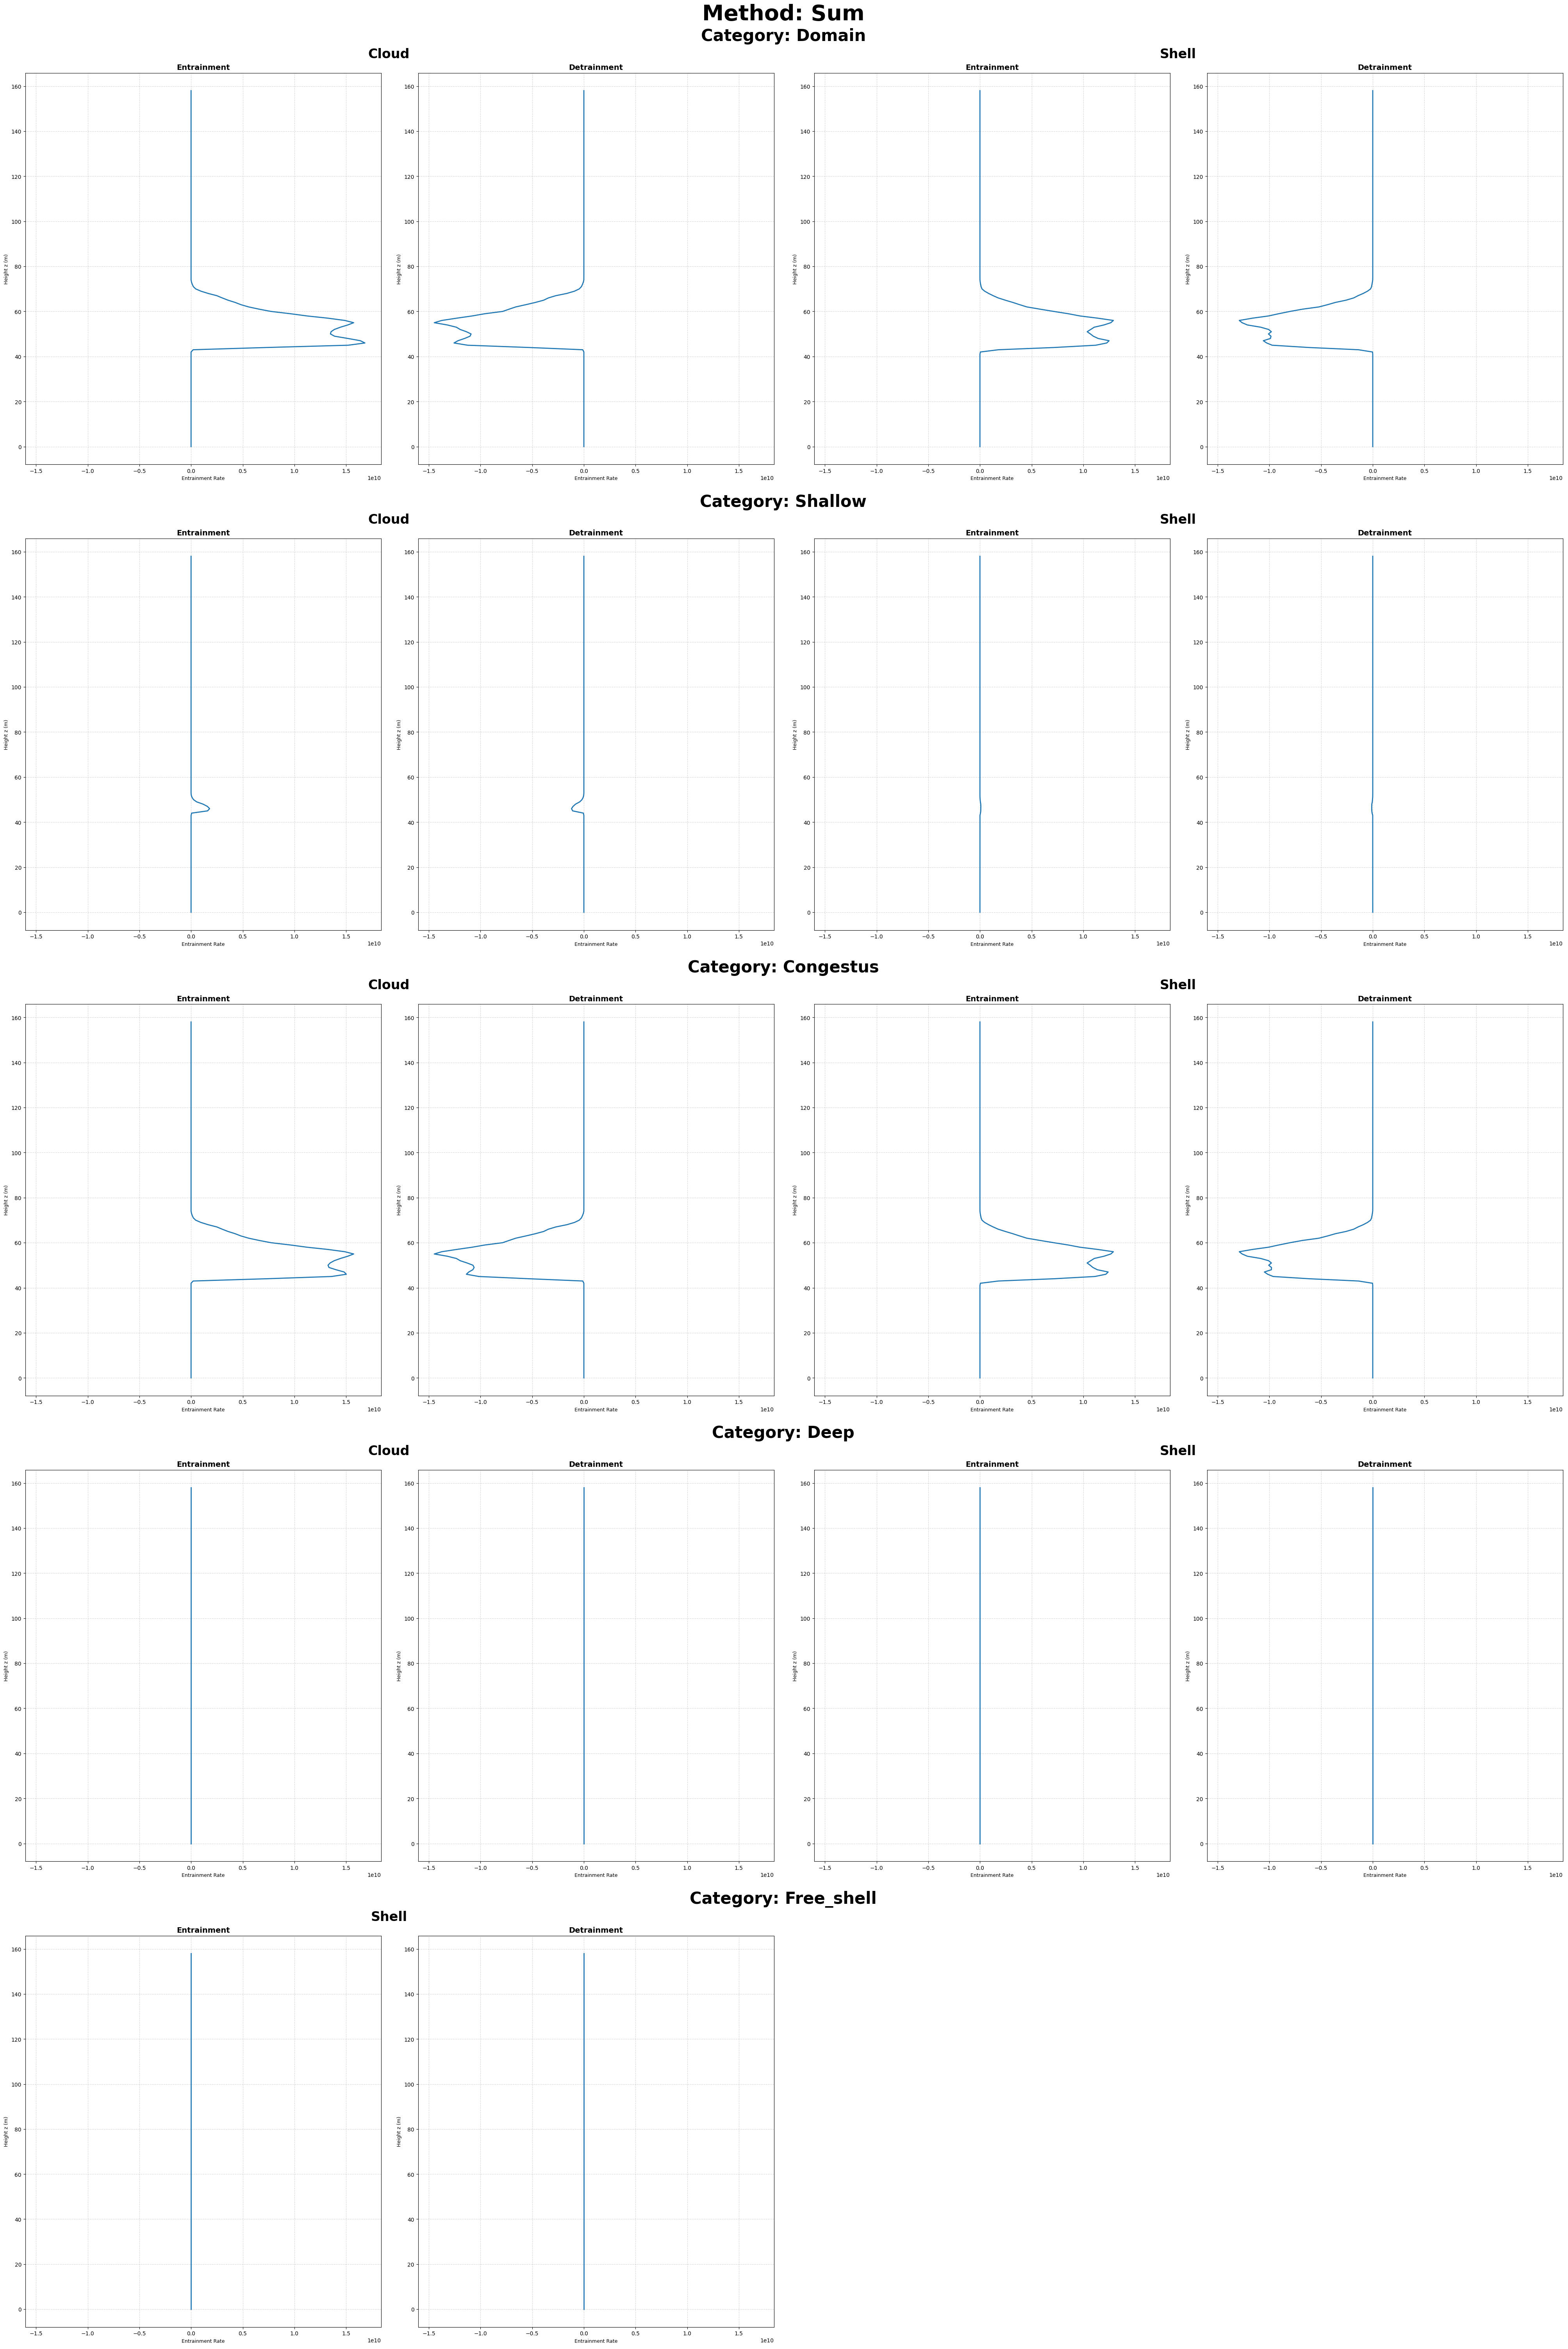

In [10]:
# Plotting

BODY_GROUP_STRUCTURE = {
    "Normal": {
        "Cloud": ["Entrainment", "Detrainment"],
        "Shell": ["Entrainment", "Detrainment"],
    },
    "Free_shell": {
        "Shell": ["Entrainment", "Detrainment"],
    },
}

SUB_GROUP_STRUCTURE = {
    "Domain": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Shallow": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Congestus": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Deep": BODY_GROUP_STRUCTURE["Normal"].copy(),
    "Free_shell": BODY_GROUP_STRUCTURE["Free_shell"].copy()
}

GROUPS_STRUCTURE = {
    "Average": SUB_GROUP_STRUCTURE.copy(),
    "Sum": SUB_GROUP_STRUCTURE.copy()
}

# --- STEP 1: Compute true global bounds ---
global_x_min, global_x_max = 0.0, 0.0

for mid, bodies in GROUPS_STRUCTURE["Sum"].items():
    for body, e_types in GROUPS_STRUCTURE["Sum"][mid].items():
        for e_type in e_types:
            group_path = f"/Sum/{mid}/{body}/{e_type}"
            try:
                with xr.open_dataset(file_path, group=group_path) as ds:
                    vals = ds["e"].isel(time=t).values
                    global_x_min = min(global_x_min, np.nanmin(vals))
                    global_x_max = max(global_x_max, np.nanmax(vals))
            except Exception:
                pass

# Add a 5% visual padding buffer so lines don't hit the axis spine
x_pad = (global_x_max - global_x_min) * 0.05
global_x_max += x_pad
global_x_min -= x_pad


num_types = 1
num_categories = 5
num_bodies = 2
num_e_types = 2
graph_width = num_categories * num_bodies
graph_height = num_types * num_categories

fig = plt.figure(figsize=(4 * graph_width, 12 * graph_height), layout='constrained')
if num_types == 1:
    sb_types = [fig.subfigures(nrows=1, ncols=1)]
else:
    sb_types = fig.subfigures(nrows=num_types, ncols=1)

i = 0
for top in ["Sum"]: #GROUPS_STRUCTURE.keys():
    sb_types[i].suptitle(f"Method: {top}", fontsize=40, weight='bold')
    sb_cats = sb_types[i].subfigures(nrows=num_categories, ncols=1) # One subfigure per row
    
    j = 0
    for mid, bodies in GROUPS_STRUCTURE[top].items():
        sb_cats[j].suptitle(f"Category: {mid}", fontsize=30, weight='bold')
        sb_body = sb_cats[j].subfigures(nrows=1, ncols=num_bodies)

        k = 0
        for body, e_types in GROUPS_STRUCTURE[top][mid].items():
            sb_body[k].suptitle(f"{body}", fontsize=24, weight='bold')
            sb_e_type = sb_body[k].subplots(nrows=1, ncols=num_e_types)
            L = 0
            for e_type in e_types:
                ax = sb_e_type[L]
                

                group_path = f"/{top}/{mid}/{body}/{e_type}"

                try:
                    # 2. Open the specific group using xarray
                    with xr.open_dataset(file_path, group=group_path) as ds:
                        # Let's assume the variable is named 'entrainment' with dimensions (time, z)
                        # Slicing for the current timestep 't'
                        profile = ds["e"].isel(time=t)
                        
                        # 3. Plot the 1D profile (z-axis usually on the vertical y-axis)
                        profile.plot(
                            ax=ax, 
                            y="z", 
                            color='tab:blue', 
                            lw=2, 
                            label=f"{body} {e_type}"
                        )
                        
                        # Aesthetics
                        ax.set_xlabel("Entrainment Rate", fontsize=9)
                        ax.set_ylabel("Height z (m)", fontsize=9)
                        ax.set_xlim(global_x_min, global_x_max)
                        ax.grid(True, linestyle="--", alpha=0.5)
                        
                except Exception as e:
                    # Handle cases where a specific group might be missing from the file
                    ax.text(0.5, 0.5, f"Group not found:\n{group_path}", 
                            ha='center', va='center', transform=ax.transAxes, color='red')
                    print(f"⚠️ Error opening group {group_path}: {e}")

                # open group and plot using xarray
                ax.set_title(f"{e_type}", fontsize=14, weight='bold')
                L += 1
            k += 1

        j += 1

    i += 1

plt.show()

In [ ]:
with xr.open_dataset(file_path, group="Sum/Domain/Shell") as ds:
    ds_e = ds

In [ ]:
np.unique(ds_e.entrainment.values)

In [3]:
ds_e = xr.open_dataset("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS/slab_shell_label_entrainment.nc", decode_times=False)
np.unique(ds_e.sel(time=154800).shell_label_entrainment.values)

array([0.00000000e+00, 5.76860476e+00, 5.20746346e+01, 7.03198013e+01,
       8.46310272e+01, 1.15117928e+02, 1.32241898e+02, 1.94334564e+02,
       1.95708069e+02, 2.30070480e+02, 2.39261749e+02, 2.48901688e+02,
       3.46674011e+02, 3.96778107e+02, 4.16911743e+02, 4.19472992e+02,
       5.36442444e+02, 5.39328491e+02, 6.05714722e+02, 6.46238953e+02,
       7.77470947e+02, 7.85947571e+02, 8.16718079e+02, 1.22996411e+03,
       1.26416577e+03, 1.29570227e+03, 1.31827417e+03, 1.36740710e+03,
       1.48704785e+03, 1.56610205e+03, 2.08947754e+03, 2.20924292e+03,
       2.25623315e+03, 2.28217896e+03, 2.28334985e+03, 2.42122974e+03,
       2.42780591e+03, 2.80596533e+03, 2.84260034e+03, 3.00674146e+03,
       3.01424463e+03, 3.18216309e+03, 3.18222095e+03, 3.19211475e+03,
       3.51394824e+03, 3.56037866e+03, 3.65190430e+03, 3.75396045e+03,
       3.83654785e+03, 4.00824316e+03, 4.11789258e+03, 4.18249512e+03,
       4.24561963e+03, 4.30161914e+03, 4.40161230e+03, 4.41555859e+03,
      

In [4]:
ds_e.z.values

array([1.0000e+01, 3.0000e+01, 5.2000e+01, 7.6000e+01, 1.0200e+02,
       1.3100e+02, 1.6300e+02, 2.0000e+02, 2.4000e+02, 2.8000e+02,
       3.2000e+02, 3.6000e+02, 4.0000e+02, 4.4000e+02, 4.8000e+02,
       5.2000e+02, 5.6000e+02, 6.0000e+02, 6.4000e+02, 6.8000e+02,
       7.2000e+02, 7.6000e+02, 8.0000e+02, 8.4000e+02, 8.8000e+02,
       9.2000e+02, 9.6000e+02, 1.0000e+03, 1.0400e+03, 1.0800e+03,
       1.1200e+03, 1.1600e+03, 1.2000e+03, 1.2400e+03, 1.2800e+03,
       1.3200e+03, 1.3600e+03, 1.4000e+03, 1.4400e+03, 1.4800e+03,
       1.5200e+03, 1.5600e+03, 1.6000e+03, 1.6400e+03, 1.6800e+03,
       1.7200e+03, 1.7600e+03, 1.8000e+03, 1.8400e+03, 1.8800e+03,
       1.9200e+03, 1.9600e+03, 2.0000e+03, 2.0400e+03, 2.0800e+03,
       2.1200e+03, 2.1600e+03, 2.2000e+03, 2.2400e+03, 2.2800e+03,
       2.3200e+03, 2.3600e+03, 2.4000e+03, 2.4400e+03, 2.4800e+03,
       2.5200e+03, 2.5600e+03, 2.6000e+03, 2.6400e+03, 2.6800e+03,
       2.7200e+03, 2.7600e+03, 2.8000e+03, 2.8400e+03, 2.8800e

In [5]:
ds_mask = xr.open_dataset("/mnt/stor-pool-01/projects/heus/ShellAnalysis/SEUS/congestus_mask.nc", decode_times=False)
ds_mask.z.values

array([1.0000e+01, 3.0000e+01, 5.2000e+01, 7.6000e+01, 1.0200e+02,
       1.3100e+02, 1.6300e+02, 2.0000e+02, 2.4000e+02, 2.8000e+02,
       3.2000e+02, 3.6000e+02, 4.0000e+02, 4.4000e+02, 4.8000e+02,
       5.2000e+02, 5.6000e+02, 6.0000e+02, 6.4000e+02, 6.8000e+02,
       7.2000e+02, 7.6000e+02, 8.0000e+02, 8.4000e+02, 8.8000e+02,
       9.2000e+02, 9.6000e+02, 1.0000e+03, 1.0400e+03, 1.0800e+03,
       1.1200e+03, 1.1600e+03, 1.2000e+03, 1.2400e+03, 1.2800e+03,
       1.3200e+03, 1.3600e+03, 1.4000e+03, 1.4400e+03, 1.4800e+03,
       1.5200e+03, 1.5600e+03, 1.6000e+03, 1.6400e+03, 1.6800e+03,
       1.7200e+03, 1.7600e+03, 1.8000e+03, 1.8400e+03, 1.8800e+03,
       1.9200e+03, 1.9600e+03, 2.0000e+03, 2.0400e+03, 2.0800e+03,
       2.1200e+03, 2.1600e+03, 2.2000e+03, 2.2400e+03, 2.2800e+03,
       2.3200e+03, 2.3600e+03, 2.4000e+03, 2.4400e+03, 2.4800e+03,
       2.5200e+03, 2.5600e+03, 2.6000e+03, 2.6400e+03, 2.6800e+03,
       2.7200e+03, 2.7600e+03, 2.8000e+03, 2.8400e+03, 2.8800e